# **Datos del Estudiante**

Nombre:

CI:

# **Clase 4 — Modelos Supervisados II: SVM y Redes Neuronales (MLP)**

**Objetivos**
- Comprender modelos no lineales potentes: SVM (kernels) y MLP (redes neuronales multicapa).
- Ver la formulación matemática esencial y las decisiones de optimización.
- Implementar y comparar SVM (RBF) y MLP con `scikit-learn`.
- Visualizar fronteras de decisión en datasets no lineales (moons, circles).
- Realizar ejercicios prácticos y análisis de hiperparámetros.


## **Imports y configuración inicial**

In [5]:
# Imports básicos
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib
import os

# Crear carpeta para guardar figuras
os.makedirs('figures', exist_ok=True)


## **Funciones auxiliares: plot de frontera y utilidades**

Usa la función de explicar codigo. Explica con tus palabras para que sierve la función plot_decision_boundary.

In [6]:
def plot_decision_boundary(clf, X, y, ax=None, title=None, cmap='coolwarm', proba=False):
    """
    Dibuja la frontera de decisión de un clasificador entrenado.
    - clf: clasificador (debe tener predict o predict_proba/decision_function)
    - X: array (n_samples, 2)
    - y: etiquetas
    - ax: matplotlib axis opcional
    - proba: si True intenta usar predict_proba para contornos
    """
    if ax is None:
        ax = plt.gca()
    x_min, x_max = X[:,0].min() - .5, X[:,0].max() + .5
    y_min, y_max = X[:,1].min() - .5, X[:,1].max() + .5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    try:
        if proba and hasattr(clf, "predict_proba"):
            Z = clf.predict_proba(grid)[:,1]
            Z = Z.reshape(xx.shape)
            cs = ax.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.4)
        else:
            Z = clf.predict(grid)
            Z = Z.reshape(xx.shape)
            ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)
    except Exception:
        # fallback: usar decision_function si existe
        if hasattr(clf, "decision_function"):
            Z = clf.decision_function(grid)
            Z = Z.reshape(xx.shape)
            ax.contourf(xx, yy, Z > 0, alpha=0.3, cmap=cmap)
        else:
            raise
    ax.scatter(X[:,0], X[:,1], c=y, s=30, edgecolor='k', cmap=cmap)
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    if title:
        ax.set_title(title)

def save_figure(fig, fname):
    path = os.path.join('figures', fname)
    fig.savefig(path, dpi=200, bbox_inches='tight')
    print(f"Saved {path}")


## **Generar datasets no lineales (moons y circles)**

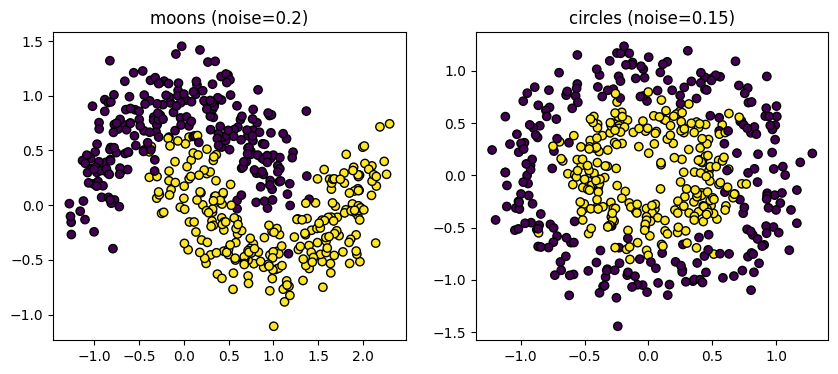

In [7]:
# Dataset: moons
X_moons, y_moons = make_moons(n_samples=500, noise=0.2, random_state=0)

# Dataset: circles
X_circles, y_circles = make_circles(n_samples=500, noise=0.15, factor=0.5, random_state=1)

# Mostrar ejemplos
fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].scatter(X_moons[:,0], X_moons[:,1], c=y_moons, edgecolor='k')
axes[0].set_title('moons (noise=0.2)')
axes[1].scatter(X_circles[:,0], X_circles[:,1], c=y_circles, edgecolor='k')
axes[1].set_title('circles (noise=0.15)')
plt.show()


> Consulta en la notebookLM sobre las funciones make_moons, make_circles, make_classification y explica en que se diferencian:

## **Entrenamiento y visualización: moons (SVM vs MLP)**

Moons - SVM acc: 0.94
Moons - MLP acc: 0.9533333333333334
Saved figures/svm_moons_vs_mlp_moons.png


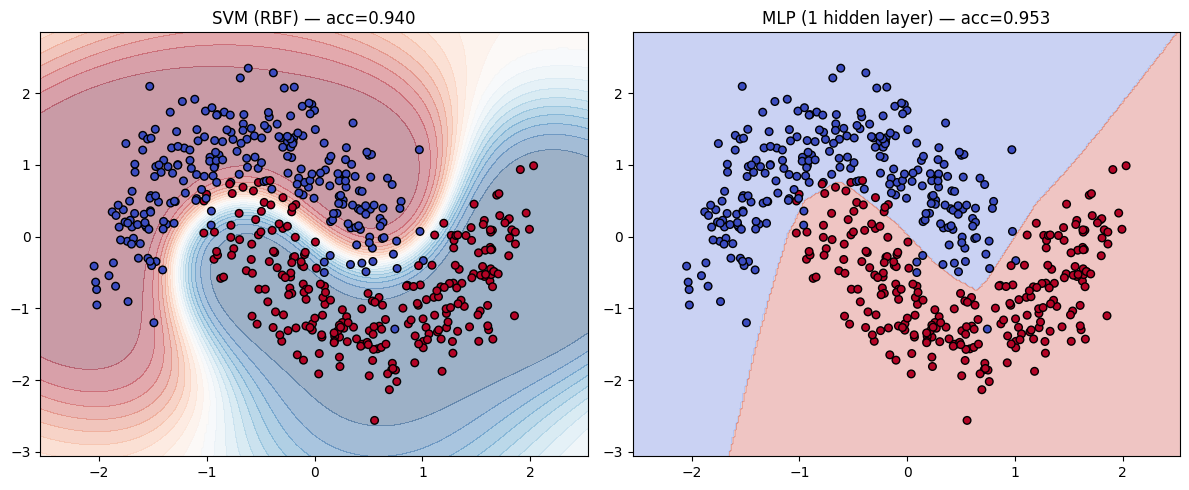

In [10]:
# Preparar datos (train/test + escalado)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_moons, y_moons, test_size=0.3, random_state=42)
scaler_m = StandardScaler().fit(X_train_m)
X_train_m_s = scaler_m.transform(X_train_m)
X_test_m_s = scaler_m.transform(X_test_m)
X_moons_s = scaler_m.transform(X_moons)

# Modelos
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
mlp_moons = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=1000, random_state=42)

# Entrenar
svm_rbf.fit(X_train_m_s, y_train_m)
mlp_moons.fit(X_train_m_s, y_train_m)

# Evaluar
pred_svm_m = svm_rbf.predict(X_test_m_s)
pred_mlp_m = mlp_moons.predict(X_test_m_s)
print("Moons - SVM acc:", accuracy_score(y_test_m, pred_svm_m))
print("Moons - MLP acc:", accuracy_score(y_test_m, pred_mlp_m))

# Plot y guardar
fig, axes = plt.subplots(1, 2, figsize=(12,5))
plot_decision_boundary(svm_rbf, X_moons_s, y_moons, ax=axes[0], title=f"SVM (RBF) — acc={accuracy_score(y_test_m, pred_svm_m):.3f}", proba=True)
plot_decision_boundary(mlp_moons, X_moons_s, y_moons, ax=axes[1], title=f"MLP (1 hidden layer) — acc={accuracy_score(y_test_m, pred_mlp_m):.3f}")
plt.tight_layout()
save_figure(fig, 'svm_moons_vs_mlp_moons.png')
plt.show()


> Respoden entre lineas

1.   Qué función cumple el parámetro C en SVC?
2.   Cómo afecta el hiperparametro degree al modelo de SVC?
3.   Qué otras funciones de activación permite la función MLPClassifier?
4.   Cómo afecta el solver sgd al MLPClassifier en su exactitud? Solicita ayuda al chatbot de la notebookLM para entender las diferencias en la exactitud al cambiar el solver de adam a sgd.  





## **Guardar modelos y artefactos**

Usa la función de explicar codigo y explica con tus palabras la utilidad de su implementación

In [13]:
joblib.dump(svm_rbf, 'figures/svm_moons_model.joblib')
joblib.dump(mlp_moons, 'figures/mlp_moons_model.joblib')
joblib.dump(scaler_m, 'figures/scaler_moons.joblib')

# Preparar datos (train/test + escalado) para circles
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_circles, y_circles, test_size=0.3, random_state=42)
scaler_c = StandardScaler().fit(X_train_c)
X_train_c_s = scaler_c.transform(X_train_c)
X_test_c_s = scaler_c.transform(X_test_c)

# Modelos para circles
svm_rbf_c = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
mlp_circles = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=1000, random_state=42)

# Entrenar modelos para circles
svm_rbf_c.fit(X_train_c_s, y_train_c)
mlp_circles.fit(X_train_c_s, y_train_c)

joblib.dump(svm_rbf_c, 'figures/svm_circles_model.joblib')
joblib.dump(mlp_circles, 'figures/mlp_circles_model.joblib')
joblib.dump(scaler_c, 'figures/scaler_circles.joblib')

print("Modelos y scalers guardados en carpeta 'figures'.")

Modelos y scalers guardados en carpeta 'figures'.


## **Ejemplo de Carga y Uso de Modelos Guardados**

In [14]:
print('--- Ejemplo de Carga y Uso de Modelos Guardados ---\n')

# 1. Cargar el modelo y el scaler
loaded_svm_moons = joblib.load('figures/svm_moons_model.joblib')
loaded_scaler_moons = joblib.load('figures/scaler_moons.joblib')

print('Modelos y scalers cargados exitosamente.\n')

# 2. Generar un nuevo punto de datos para predecir (o tomar uno del conjunto de prueba)
# Usaremos un punto de X_test_m para demostrar la funcionalidad
new_data_point_original = X_test_m[0].reshape(1, -1) # reshape para que sea 2D

print(f'Punto de datos original para predecir: {new_data_point_original[0]}\n')

# 3. Escalar el nuevo punto de datos usando el scaler cargado
new_data_point_scaled = loaded_scaler_moons.transform(new_data_point_original)

print(f'Punto de datos escalado: {new_data_point_scaled[0]}\n')

# 4. Realizar una predicción con el modelo cargado
prediction = loaded_svm_moons.predict(new_data_point_scaled)

print(f'La predicción del modelo cargado para este punto es: {prediction[0]}\n')

# Para verificar, comparemos con la etiqueta real (si es conocida)
actual_label = y_test_m[0]
print(f'La etiqueta real (conocida) para este punto es: {actual_label}\n')

if prediction[0] == actual_label:
    print('¡La predicción coincide con la etiqueta real!')
else:
    print('La predicción NO coincide con la etiqueta real.')


--- Ejemplo de Carga y Uso de Modelos Guardados ---

Modelos y scalers cargados exitosamente.

Punto de datos original para predecir: [ 1.09250531 -0.37335468]

Punto de datos escalado: [ 0.65767012 -1.15397239]

La predicción del modelo cargado para este punto es: 1

La etiqueta real (conocida) para este punto es: 1

¡La predicción coincide con la etiqueta real!


## **Visualizaciones separadas (guardar SVM y MLP por separado)**

In [16]:
# Si prefieres archivos separados por modelo, generarlos así:

X_circles_s = scaler_c.transform(X_circles)

# Moons: SVM
fig, ax = plt.subplots(1,1,figsize=(6,5))
plot_decision_boundary(svm_rbf, X_moons_s, y_moons, ax=ax, title="SVM (RBF) — moons", proba=True)
save_figure(fig, 'svm_moons.png')
plt.close(fig)

# Moons: MLP
fig, ax = plt.subplots(1,1,figsize=(6,5))
plot_decision_boundary(mlp_moons, X_moons_s, y_moons, ax=ax, title="MLP (1 hidden layer) — moons")
save_figure(fig, 'mlp_moons.png')
plt.close(fig)

# Circles: SVM
fig, ax = plt.subplots(1,1,figsize=(6,5))
plot_decision_boundary(svm_rbf_c, X_circles_s, y_circles, ax=ax, title="SVM (RBF) — circles", proba=True)
save_figure(fig, 'svm_circles.png')
plt.close(fig)

# Circles: MLP
fig, ax = plt.subplots(1,1,figsize=(6,5))
plot_decision_boundary(mlp_circles, X_circles_s, y_circles, ax=ax, title="MLP (2 hidden layers) — circles")
save_figure(fig, 'mlp_circles.png')
plt.close(fig)


Saved figures/svm_moons.png
Saved figures/mlp_moons.png
Saved figures/svm_circles.png
Saved figures/mlp_circles.png


## **Análisis de sensibilidad a hiperparámetros**

In [17]:
# Ejemplo: variar C y gamma en SVM (moons) y observar accuracy en test
from itertools import product

Cs = [0.1, 1, 10]
gammas = ['scale', 0.5, 1.0]
results = []

for C, g in product(Cs, gammas):
    clf = SVC(kernel='rbf', C=C, gamma=g, random_state=42)
    clf.fit(X_train_m_s, y_train_m)
    acc = accuracy_score(y_test_m, clf.predict(X_test_m_s))
    results.append((C, g, acc))

import pandas as pd
df_res = pd.DataFrame(results, columns=['C','gamma','acc'])
print(df_res.pivot(index='C', columns='gamma', values='acc'))


gamma       0.5       1.0     scale
C                                  
0.1    0.906667  0.933333  0.906667
1.0    0.940000  0.960000  0.940000
10.0   0.966667  0.966667  0.966667


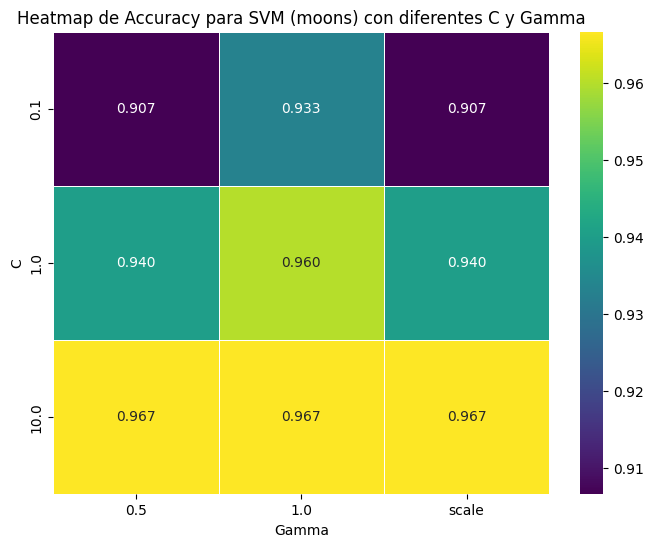

In [18]:
import seaborn as sns

# Preparar los datos para el heatmap
# El dataframe df_res ya tiene los resultados de la sensibilidad
# lo pivotamos como se hizo antes para el print
heatmap_data = df_res.pivot(index='C', columns='gamma', values='acc')

# Crear el heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, cmap='viridis', fmt=".3f", linewidths=.5)
plt.title('Heatmap de Accuracy para SVM (moons) con diferentes C y Gamma')
plt.xlabel('Gamma')
plt.ylabel('C')
plt.show()


> Interpreta los resultados del analisis de sensibilidad a hiperparámetros:

# **Ejercicios prácticos**

1. **Explorar hiperparámetros SVM**
   - En el dataset `moons`, haga una búsqueda en cuadrícula (GridSearchCV) sobre `C` y `gamma`.
   - Reporte la mejor combinación y compare la frontera resultante con la frontera por defecto.

2. **Arquitectura MLP**
   - En `circles`, pruebe distintas arquitecturas: una capa oculta con 50, 100, 200 unidades; dos capas con (50,50), (100,50), (100,100).
   - Compare accuracy y tiempos de entrenamiento. ¿Qué arquitectura generaliza mejor?

3. **Regularización y early stopping**
   - Active `early_stopping=True` en `MLPClassifier` y compare la convergencia y la generalización.
   - Añada `alpha` (regularización L2) y observe su efecto.

4. **Visualización y PCA**
   - Si dispone de un dataset con más de 2 atributos, aplique PCA a 2 componentes y visualice las fronteras de decisión de SVM y MLP en el espacio proyectado.

5. **Comparación cuantitativa**
   - Para ambos datasets, calcule matriz de confusión y reporte precision/recall/F1 para SVM y MLP.
   - Discuta en qué regiones del espacio cada modelo comete más errores.

6. **Actividad avanzada (opcional)**
   - Implementar un perceptrón multicapa simple (forward + backprop) desde cero para un dataset 2D y comparar su frontera con `MLPClassifier`.


# **Recursos y lecturas recomendadas**

- Cristianini, N. & Shawe-Taylor, J. — *An Introduction to Support Vector Machines and Other Kernel-based Learning Methods*.
- Goodfellow, I., Bengio, Y., Courville, A. — *Deep Learning* (capítulos introductorios sobre MLP y optimización).
- Documentación scikit-learn: `SVC`, `MLPClassifier`, `GridSearchCV`.
- Notebooks de ejemplo en la galería de scikit-learn (datasets y visualizaciones).


# Rúbrica de Evaluación

| Criterio | Descripción | Puntos |
|---|---:|---:|
| Implementación correcta | Código que entrena SVM y MLP según instrucciones y produce resultados reproducibles | **30** |
| Visualizaciones | Fronteras de decisión claras, bien etiquetadas y guardadas como PNG | **20** |
| Análisis de resultados | Interpretación de accuracy, matriz de confusión y discusión de diferencias entre modelos | **15** |
| Experimentos de hiperparámetros | Búsqueda/variación de hiperparámetros y resumen de hallazgos (tablas/plots) | **10** |
| Calidad del código | Legibilidad, comentarios, uso de funciones y buenas prácticas (scaling, seed) | **10** |
| Reproducibilidad y artefactos | Modelos y scalers guardados; instrucciones claras para reproducir y exportar figuras | **10** |
| Entrega y presentación | Notebook ordenado, celdas ejecutables, resultados exportados y breve informe final | **5** |

**Total: 100 puntos**

**Escala sugerida**
- 90–100: Excelente
- 75–89: Bueno
- 60–74: Aceptable
- <60: Insuficiente

